In [1]:
import torch
from tqdm.auto import tqdm
import os
from collections import defaultdict

from src.models.reid import ReIDModel
from src.utils.segment_info import get_segment_groups, get_attention_groups
from src.metric import DistanceMetric

from IPython.display import clear_output

In [2]:
print("Cuda Available:", torch.cuda.is_available())
print("Cuda Current Device:", torch.cuda.current_device())

Cuda Available: True
Cuda Current Device: 0


In [3]:
# Parameters
class Config:
    device = torch.device("cuda")

    batch_size = 32

    # Model Hyperparameters
    model_variant = "hrnet32" # "m3large", "m3small", "hrnet32"
    seg_variant = "5pf" # "2p(f)", "4p(f)", "5p(f)"
    emb_len = 256
    input_resolution= (192, 64)

    segment_groups = get_segment_groups(seg_variant)
    segment_num = len(segment_groups)
    attention_groups = get_attention_groups(seg_variant)
    attention_num = len(attention_groups)

    def get_default_threshold():
        print("No pre-defined threshold found. Using default threshold values.")
        return dict(concat_dist=3.7,
                    dist_mean=1.5)
    threshold_presets = defaultdict(get_default_threshold)
    
    threshold_presets["reid_hrnet32_5pf256e_64x192"] = dict(concat_dist=3.7,
                                                            dist_mean=1.5)
    threshold_presets["reid_m3large_5pf256e_64x192"] = dict(concat_dist=3.3,
                                                            dist_mean=1.3)
    threshold_presets["reid_m3small_5pf256e_64x192"] = dict(concat_dist=2.4,
                                                            dist_mean=1.0)

    default_distance_metric = "concat_dist" # 'concat_dist', 'dist_mean'
    distance_metric = DistanceMetric(default_distance_metric)
    default_thresholds = threshold_presets[ReIDModel.get_model_name(model_variant, seg_variant, emb_len, input_resolution)]

    input_name = "input"
    v_score_name = "visibility_scores"
    emb_vec_name = "embedding_vectors"

## Train Model

In [4]:
from torch.optim import lr_scheduler, Adam

from src.data import get_dataloaders
from src.loss.seg_loss import SegLoss
from src.loss.class_loss import ClassLoss
from src.loss.triplet_loss import TripletLoss

In [5]:
class TrainConfig:
    learning_rate = 0.00035
    batch_id = 16
    batch_image = 4
    body_part_loss_weight = 6

    train_epoch = 200
    resume_epoch = None

    epoch_save_steps = 100
    seed = 21

In [6]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=False,
                  backbone_pretrained=True).to(Config.device)

val_generator = torch.Generator()

In [7]:
((seg_train_loader, re_id_train_loader),
 (seg_val_loader, re_id_val_loader)) = get_dataloaders(Config.seg_variant,
                                                       Config.input_resolution,
                                                       TrainConfig.batch_id,
                                                       TrainConfig.batch_image,
                                                       val_generator=val_generator)

loading annotations into memory...
Done (t=6.65s)
creating index...
index created!
loading annotations into memory...
Done (t=2.06s)
creating index...
index created!


In [8]:
class_nums = [len(loader.dataset.unique_ids) for loader in re_id_train_loader.loaders]
train_model = model.get_train_model(class_nums).to(Config.device)

if TrainConfig.resume_epoch is not None:
    print(f"Resume from epoch {TrainConfig.resume_epoch}")
    weight_path = train_model.weight_file_path.format(TrainConfig.resume_epoch)
    train_model.load_state_dict(torch.load(weight_path, weights_only=True))

In [9]:
reid_optimizer = Adam(train_model.parameters(), lr=TrainConfig.learning_rate, weight_decay=5e-4, amsgrad=True)
reid_scheduler = lr_scheduler.ReduceLROnPlateau(reid_optimizer, patience=5, factor=0.5)

reid_last_epoch = TrainConfig.resume_epoch if TrainConfig.resume_epoch is not None else 0
reid_last_train_loss = None
reid_last_val_loss = None

reid_best_epoch = None
reid_best_loss = None
reid_best_weight = None

seg_loss = SegLoss()
cls_loss = ClassLoss()
tpl_loss = TripletLoss()
val_tpl_loss = TripletLoss(topk=1, margin=2)

In [10]:
def reid_train(epoch):
    global reidb_last_train_loss
    if isinstance(TrainConfig.body_part_loss_weight, float) or isinstance(TrainConfig.body_part_loss_weight, int):
        body_part_loss_weight = TrainConfig.body_part_loss_weight
    else:
        body_part_loss_weight = (TrainConfig.body_part_loss_weight[0] +
                                 (epoch / TrainConfig.train_epoch) *
                                 (TrainConfig.body_part_loss_weight[1] -TrainConfig.body_part_loss_weight[0]))

    print(f"Training Epoch: {epoch}")
    train_loss = 0
    train_count = 0
    for (seg_img, seg_label), (dataset_idx, (reid_img, id_label)) in zip(seg_train_loader, re_id_train_loader):
        seg_img = seg_img.to(Config.device)
        seg_label = seg_label.to(Config.device)

        reid_img = reid_img.to(Config.device)
        id_label = id_label.to(Config.device)

        reid_optimizer.zero_grad()

        train_model.eval()

        with torch.no_grad(): 
            reid_seg = train_model.forward_segmentation(reid_img)

        train_model.train()
        # Seg
        out_seg = train_model.forward_segmentation(seg_img)

        # ReID
        emb_vec, concat_logits, foreground_logits, gap_logits = train_model(reid_img, reid_seg)

        s_loss = seg_loss(out_seg, seg_label) * body_part_loss_weight
        c_loss = (cls_loss(concat_logits[dataset_idx], id_label) +
                  cls_loss(foreground_logits[dataset_idx], id_label) +
                  cls_loss(gap_logits[dataset_idx], id_label))
        t_loss = tpl_loss(emb_vec, id_label)

        loss = s_loss + c_loss + t_loss

        print('\rSeg_Loss:%.2f  Triplet_Loss:%.2f  Class_Loss:%.2f' % (
            s_loss.data.cpu().numpy(),
            t_loss.data.cpu().numpy(),
            c_loss.data.cpu().numpy()),
              end=' ')

        loss.backward()
        reid_optimizer.step()

        train_loss += loss.item() * reid_img.shape[0]
        train_count += reid_img.shape[0]

    train_loss = train_loss / train_count
    print(f"\nTrain loss: {train_loss:.2f}")
    reid_last_train_loss = train_loss


def reid_val(epoch):
    global reid_best_epoch
    global reid_best_loss
    global reid_best_weight
    global reid_last_val_loss

    val_generator.manual_seed(TrainConfig.seed)
    train_model.eval()
    print(f"Validation on Epoch {epoch}")
    val_loss = 0
    val_count = 0
    with torch.no_grad():
        for _, (img, id_label) in re_id_val_loader:
            img = img.to(Config.device)
            id_label = id_label.to(Config.device)

            seg = train_model.forward_segmentation(img)
            emb_vec, _, _, _ = train_model(img, seg)

            t_loss = val_tpl_loss(emb_vec, id_label)
            loss = t_loss
    
            print('\rTriplet_Loss:%.2f' % (
                t_loss.data.cpu().numpy()),
                  end=' ')

            val_loss += loss.item() * img.shape[0]
            val_count += img.shape[0]

    val_loss = val_loss / val_count
    print(f"\nValidation loss: {val_loss:.2f}")
    reid_last_val_loss = val_loss

    if reid_best_loss is None or reid_best_loss > val_loss:
        reid_best_loss = val_loss
        reid_best_epoch = epoch
        reid_best_weight = train_model.state_dict()

    return val_loss

In [11]:
reid_val(reid_last_epoch)
clear_output(wait=True)

for cur_epoch in range(reid_last_epoch + 1, TrainConfig.train_epoch + 1):
    try:
        print(f"---- Training Re-Identification {cur_epoch}/{TrainConfig.train_epoch} epoch ----")
        print(f"Current best epoch: {reid_best_epoch}")
        print(f"Current best loss: {reid_best_loss:.2f}")
        if reid_last_train_loss is not None:
            print(f"Last train loss: {reid_last_train_loss:.2f}")
        print(f"Last Validation loss: {reid_last_val_loss:.2f}")
        print(f"Last Learning Rate: {reid_scheduler.get_last_lr()}")

        reid_train(cur_epoch)
        val_loss = reid_val(cur_epoch)

        reid_scheduler.step(val_loss)

        reid_last_epoch = cur_epoch

        if cur_epoch % TrainConfig.epoch_save_steps == 0 or cur_epoch == TrainConfig.train_epoch:
            weight_file_path = train_model.weight_file_path.format(cur_epoch)
            os.makedirs(os.path.dirname(weight_file_path), exist_ok=True)
            torch.save(train_model.state_dict(), weight_file_path)
            print("Checkpoint Saved")

        clear_output(wait=True)

    except KeyboardInterrupt:
        clear_output(wait=True)
        print(f"\nTraining Stopped at epoch {cur_epoch}")
        break

---- Training Re-Identification 200/200 epoch ----
Current best epoch: 36
Current best loss: 1.80
Last Validation loss: 1.81
Last Learning Rate: [1.068115234375e-08]
Training Epoch: 200
Seg_Loss:0.27  Triplet_Loss:0.36  Class_Loss:5.99 
Train loss: 5.84
Validation on Epoch 200
Triplet_Loss:2.03 
Validation loss: 1.81
Checkpoint Saved


In [12]:
print(f"Best epoch: {reid_best_epoch}")
print(f"Best loss: {reid_best_loss:.2f}")
os.makedirs(os.path.dirname(train_model.weight_file_path), exist_ok=True)
torch.save(reid_best_weight, train_model.weight_file_path.format(reid_best_epoch))
torch.save(reid_best_weight, train_model.weight_file_path.format(f"{reid_best_epoch}_best_{reid_best_loss:.2f}"))
train_model.load_state_dict(reid_best_weight)

Best epoch: 36
Best loss: 1.80


<All keys matched successfully>

### Save Pretrained

In [13]:
model.save_pretrained()

## Test

In [4]:
class TestConfig:
    reid_dataset = "market1501" # "market1501", "duke", "nia"
    random_crop = True
    filter_by_v_score = True

### Segmentation Test

In [5]:
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
from src.data import get_seg_test_data

In [6]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=True,
                  backbone_pretrained=False).to(Config.device)

In [7]:
seg_dataset, seg_dataloader = get_seg_test_data(Config.seg_variant,
                                                Config.batch_size,
                                                Config.input_resolution)

colors = [sg["color"] for sg in Config.segment_groups]
colors = torch.tensor(colors).unsqueeze(1).unsqueeze(1).expand(Config.segment_num, Config.input_resolution[0], Config.input_resolution[1], 4)

loading annotations into memory...
Done (t=0.38s)
creating index...
index created!


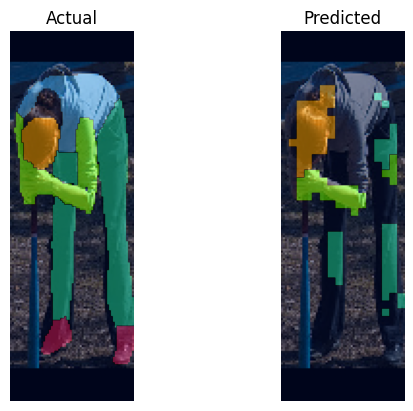

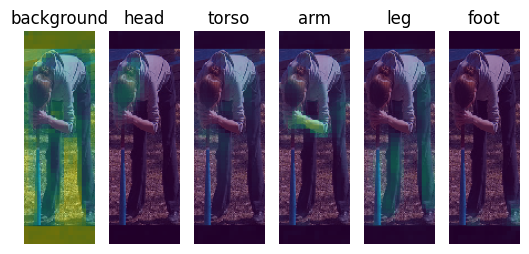

In [8]:
[image, seg] = random.choice(seg_dataset)
model.eval()

seg_result, _ = model(image.to(Config.device).unsqueeze(0))
out_seg = seg_result[0]
cmap = plt.get_cmap('viridis')

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.axis(False)
ax1.title.set_text("Actual")
ax1.imshow(image.permute(1, 2, 0))

seg_hm = seg.unsqueeze(-1).expand(-1, -1, -1, 4) * colors

for i in range(Config.segment_num):
    rgb = seg_hm[i]
    ax1.imshow(rgb)

ax2.axis(False)
ax2.title.set_text("Predicted")
ax2.imshow(image.permute(1, 2, 0))

out_seg = F.interpolate(out_seg, Config.input_resolution, mode="nearest")

out_seg_mask = out_seg.argmax(dim=1)
out_seg_mask = F.one_hot(out_seg_mask, num_classes=Config.segment_num).permute(0, 3, 1, 2)

out_seg_rgb = (out_seg_mask
               .cpu()
               .view(Config.segment_num,
                     Config.input_resolution[0],
                     Config.input_resolution[1], 1)
               .expand(-1, -1, -1, 4) * colors)

for i in range(Config.segment_num):
    rgb = out_seg_rgb[i]
    ax2.imshow(rgb)

fig, axes = plt.subplots(1, Config.segment_num)

for i in range(Config.segment_num):
    ax = axes[i]
    ax.axis(False)
    ax.imshow(image.permute(1, 2, 0))
    label = Config.segment_groups[i]["name"]
    ax.title.set_text(label)
    s = out_seg[0][i]
    rgba = cmap(s.cpu().detach())
    rgba[:,:,-1] = 0.5
    ax.imshow(rgba)

plt.show()

In [9]:
model.eval()

expected_seg = None
predicted_seg = None

with torch.no_grad():
    for images, seg in tqdm(seg_dataloader, desc="Estimate"):
        images = images.to(Config.device)
    
        seg_result, _ = model(images)
        out_seg = seg_result[0]
    
        height = out_seg.shape[2]
        width = out_seg.shape[3]
    
        seg = F.interpolate(seg, (height, width), mode="nearest")
        out_seg = out_seg.cpu().detach()
    
        if expected_seg is None:
            expected_seg = seg
            predicted_seg = out_seg
        else:
            expected_seg = torch.cat((expected_seg, seg), dim=0)
            predicted_seg = torch.cat((predicted_seg, out_seg), dim=0)

Estimate:   0%|          | 0/71 [00:00<?, ?it/s]

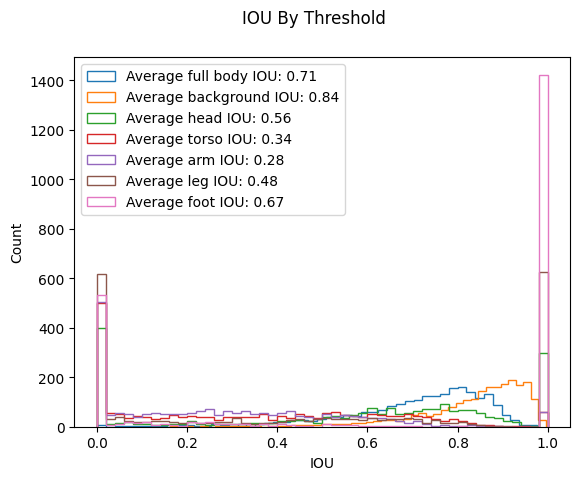

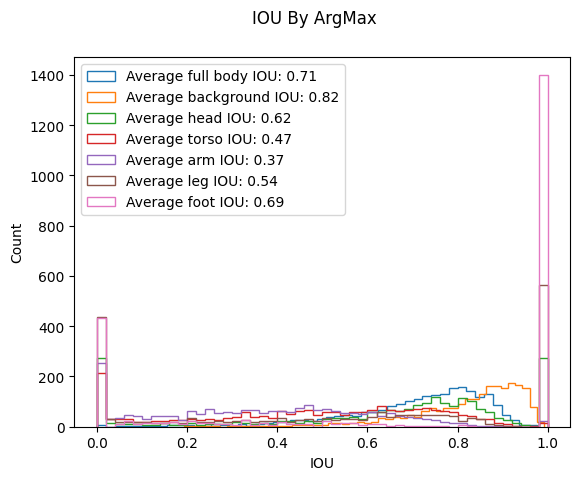

In [10]:
SCORE_THRESHOLD = 0.5
BINS = 50

expected_full_seg_mask = expected_seg[:, [i for i in range(Config.segment_num) if not Config.segment_groups[i]["is_background"]]].sum(dim=1).bool()
expected_seg_mask = expected_seg.bool()

predicted_full_seg = predicted_seg[:, [i for i in range(Config.segment_num) if not Config.segment_groups[i]["is_background"]]].sum(dim=1)

# By Threshold
predicted_full_seg_mask = predicted_full_seg >= SCORE_THRESHOLD
predicted_seg_mask = predicted_seg >= SCORE_THRESHOLD

full_seg_and = torch.logical_and(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_or = torch.logical_or(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_iou = torch.where(full_seg_or == 0.0, 1.0, full_seg_and / full_seg_or)
full_seg_iou_avg = full_seg_iou.sum() / full_seg_iou.shape[0]

seg_and = torch.logical_and(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_or = torch.logical_or(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_iou = torch.where(seg_or == 0.0, 1.0, seg_and / seg_or)
seg_iou_avg = seg_iou.sum(dim=0) / seg_iou.shape[0]


fig, ax = plt.subplots(1, 1)
fig.suptitle("IOU By Threshold")

ax.hist(full_seg_iou.sort().values,
        label=f"Average full body IOU: {full_seg_iou_avg.item():.2f}",
        bins=BINS, histtype="step")
for i in range(Config.segment_num):
    ax.hist(seg_iou[:,i].sort().values,
            label=f"Average {Config.segment_groups[i]['name']} IOU: {seg_iou_avg[i].item():.2f}",
            bins=BINS, histtype="step")
ax.legend(loc='best')
ax.set_xlabel("IOU")
ax.set_ylabel("Count")

# By ArgMax
predicted_bg_seg = predicted_seg[:, [i for i in range(Config.segment_num) if Config.segment_groups[i]["is_background"]]].sum(dim=1)
predicted_full_seg_mask = predicted_full_seg > predicted_bg_seg

predicted_seg_mask = predicted_seg.argmax(dim=1)
predicted_seg_mask = F.one_hot(predicted_seg_mask, num_classes=Config.segment_num).permute(0, 3, 1, 2).bool()

full_seg_and = torch.logical_and(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_or = torch.logical_or(expected_full_seg_mask, predicted_full_seg_mask).int().sum(dim=1).sum(dim=1)
full_seg_iou = torch.where(full_seg_or == 0.0, 1.0, full_seg_and / full_seg_or)
full_seg_iou_avg = full_seg_iou.sum() / full_seg_iou.shape[0]

seg_and = torch.logical_and(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_or = torch.logical_or(expected_seg_mask, predicted_seg_mask).int().sum(dim=2).sum(dim=2)
seg_iou = torch.where(seg_or == 0.0, 1.0, seg_and / seg_or)
seg_iou_avg = seg_iou.sum(dim=0) / seg_iou.shape[0]

fig, ax = plt.subplots(1, 1)
fig.suptitle("IOU By ArgMax")

ax.hist(full_seg_iou.sort().values,
        label=f"Average full body IOU: {full_seg_iou_avg.item():.2f}",
        bins=BINS, histtype="step")
for i in range(Config.segment_num):
    ax.hist(seg_iou[:,i].sort().values,
            label=f"Average {Config.segment_groups[i]['name']} IOU: {seg_iou_avg[i].item():.2f}",
            bins=BINS, histtype="step")
ax.legend(loc='best')
ax.set_xlabel("IOU")
ax.set_ylabel("Count")

plt.show()

### Re-ID Test

In [5]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src.data import get_re_id_test_data
from src.clustering import Person, cluster_people
import random
import numpy as np

In [6]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=True,
                  backbone_pretrained=False).to(Config.device)

In [7]:
re_id_dataset, re_id_dataloader = get_re_id_test_data(TestConfig.reid_dataset,
                                                      Config.batch_size,
                                                      Config.input_resolution,
                                                      random_crop=TestConfig.random_crop)

In [8]:
gradcam_model = model.get_gradcam_model().to(Config.device)
colormap = plt.get_cmap('viridis')

In [9]:
def matrix2d_to_rgb_heatmap(matrix):
    heatmap_rgba = colormap(matrix)

    if len(heatmap_rgba.shape) == 4:
        heatmap_rgba[:,:,:,-1] = 0.5
    else:
        heatmap_rgba[:,:,-1] = 0.5

    return heatmap_rgba

def compare_visually(idx1, idx2):
    input1 = re_id_dataset[idx1][0].to(Config.device)

    input2 = re_id_dataset[idx2][0].to(Config.device)

    att, v_scores, emb_vecs, activation_maps = gradcam_model(input1,
                                                             input2,
                                                             output_shape=Config.input_resolution)

    det = F.interpolate(att, Config.input_resolution, mode="bilinear")
    det = det.sum(dim=1)
    det = matrix2d_to_rgb_heatmap(det.cpu().detach())
    det = np.concatenate(det, axis=1)

    final_distance, part_distances = Config.distance_metric((v_scores[0], emb_vecs[0]),
                                                            (v_scores[1], emb_vecs[1]),
                                                            return_part_distances=True)

    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.title.set_text('Original Pictures')
    ax1.axis(False)
    ax1.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
    ax1.text(Config.input_resolution[1], Config.input_resolution[0] + 10,
             f"Distance: {final_distance.item():.2f}", horizontalalignment='center')

    ax2.title.set_text('Detected Person')
    ax2.axis(False)
    ax2.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
    ax2.imshow(det)

    for i in range(Config.attention_num):
        att_map = att[:, i]
        name = Config.attention_groups[i]["name"].title()

        att_map = F.interpolate(att_map.unsqueeze(0), Config.input_resolution, mode="bilinear").squeeze(0)
        att_map = matrix2d_to_rgb_heatmap(att_map.cpu().detach())
        att_map = np.concatenate(att_map, axis=1)

        maps = activation_maps[i].cpu()
        maps = matrix2d_to_rgb_heatmap(maps)
        maps = np.concatenate(maps, axis=1)

        fig, (ax1, ax2) = plt.subplots(1, 2)

        fig.suptitle(f'Comparison by parts: {name}')

        ax1.title.set_text('Segment Heatmap')
        ax1.axis(False)
        ax1.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
        ax1.imshow(att_map)
        ax1.text(0.5 * Config.input_resolution[1], Config.input_resolution[0] + 10,
                 f"Vis Score: {v_scores[0, i].item():.2f}", horizontalalignment='center')
        ax1.text(Config.input_resolution[1] + 0.5 * Config.input_resolution[1], Config.input_resolution[0] + 10,
                 f"Vis Score: {v_scores[1, i].item():.2f}", horizontalalignment='center')

        ax2.title.set_text('Distance')
        ax2.axis(False)
        ax2.imshow(torch.cat((input1.permute(1, 2, 0), input2.permute(1, 2, 0)), dim=1).cpu())
        ax2.imshow(maps)
        ax2.text(Config.input_resolution[1], Config.input_resolution[0] + 10,
                 f"Distance Score: {part_distances[i].item():.2f}", horizontalalignment='center')

    plt.show()

Different Identity Comparison Result:


/home/juhonam/workspace/realtime-re-id/re-id/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


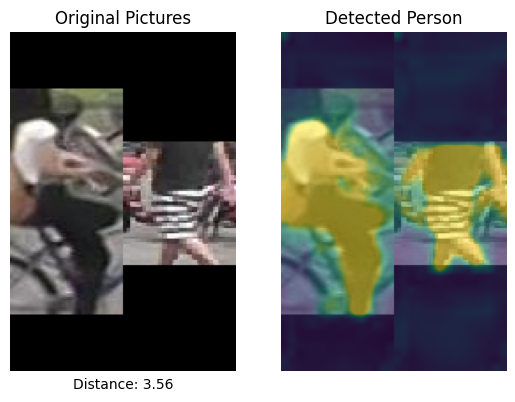

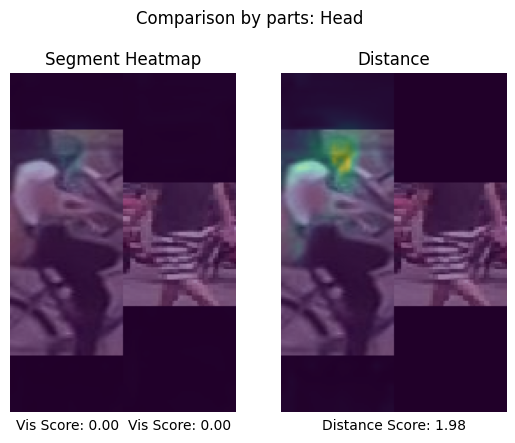

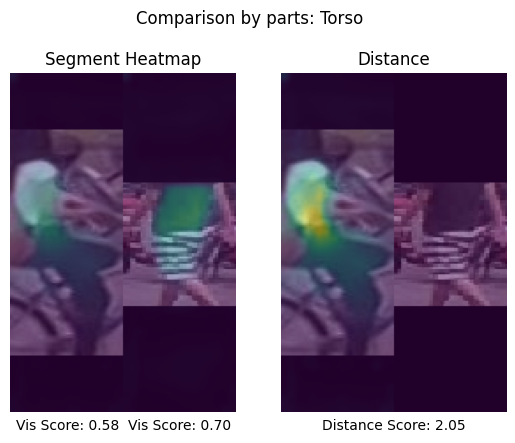

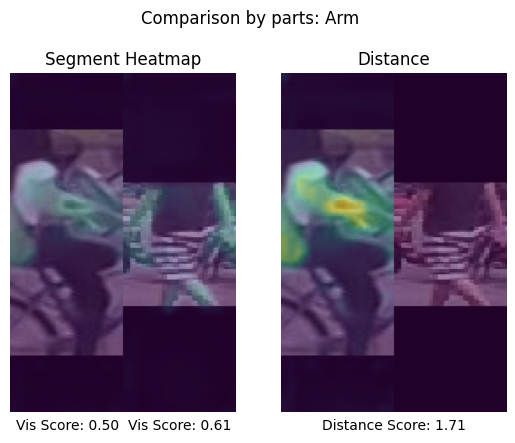

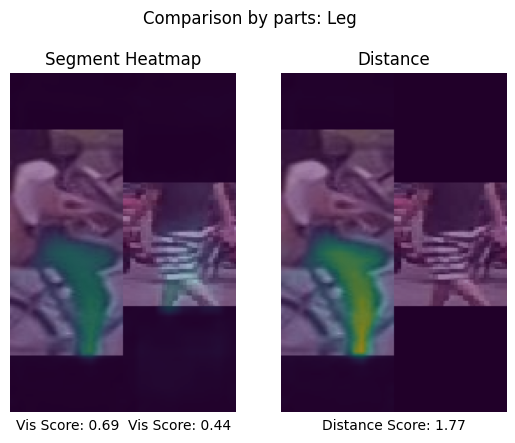

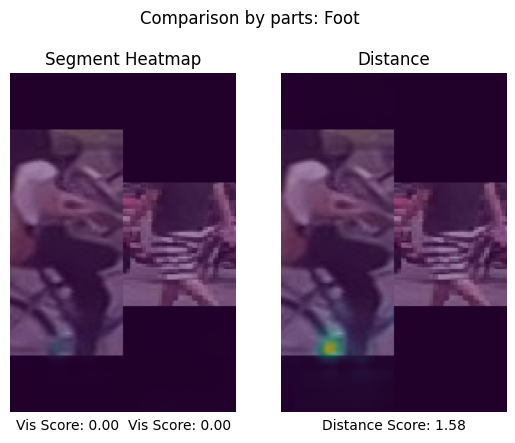

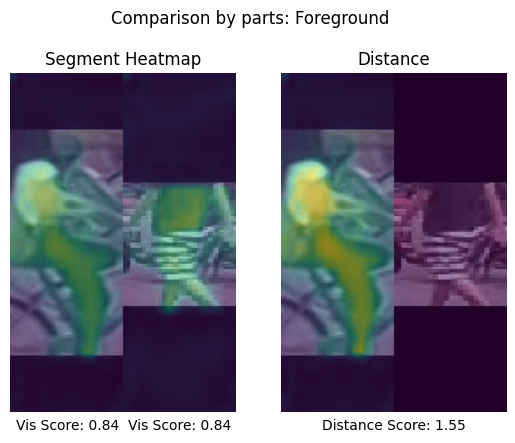

In [10]:
[id1, id2] = random.sample(re_id_dataset.unique_ids, k=2)
idx1 = random.choice(re_id_dataset.get_indexes_by_id(id1))
idx2 = random.choice(re_id_dataset.get_indexes_by_id(id2))

print("Different Identity Comparison Result:")
compare_visually(idx1, idx2)

Same Identity Comparison Result:


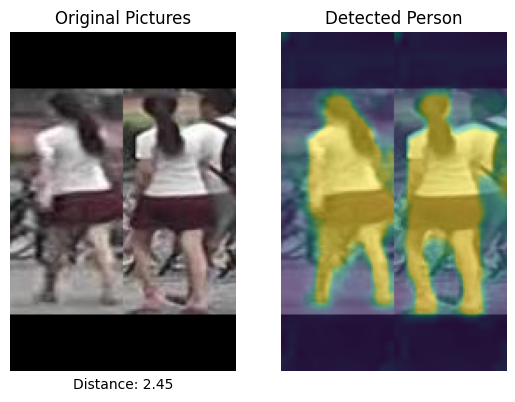

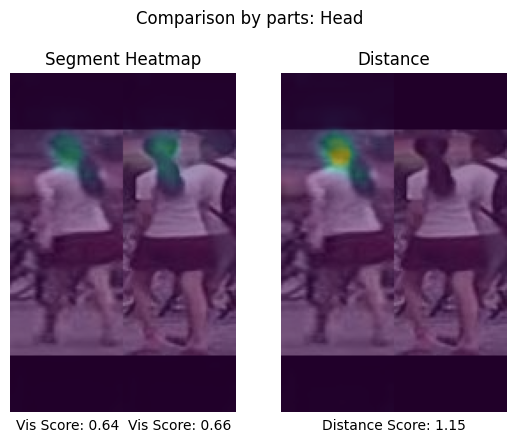

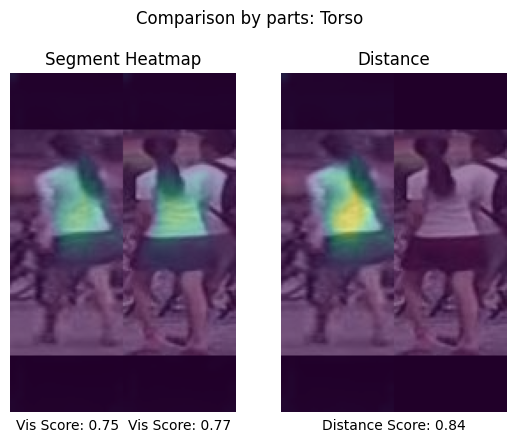

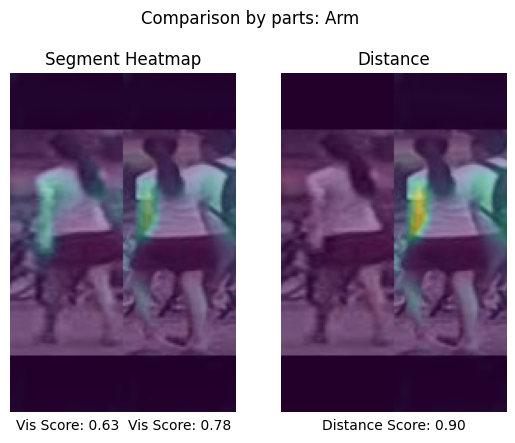

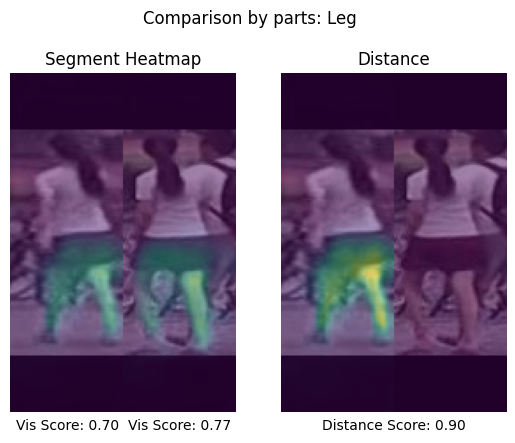

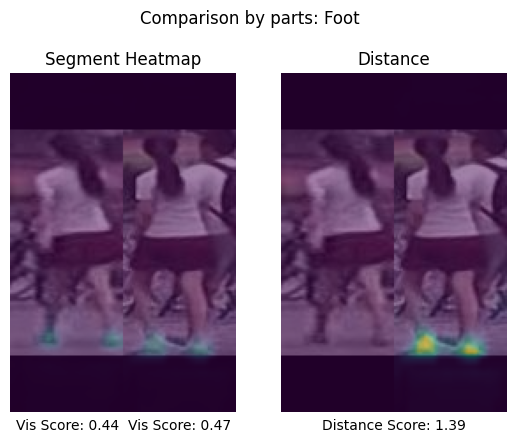

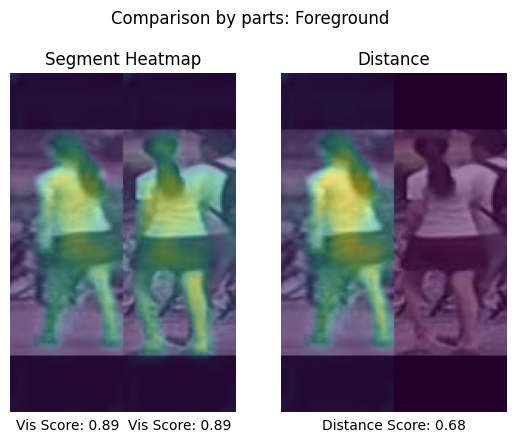

In [11]:
id_ = random.choice(re_id_dataset.unique_ids)
[idx1, idx2] = random.sample(re_id_dataset.get_indexes_by_id(id_), k=2)

print("Same Identity Comparison Result:")
compare_visually(idx1, idx2)

In [12]:
model.eval()
v_scores = torch.FloatTensor()
emb_vecs = torch.FloatTensor()

with torch.no_grad():
    for (inputs, _) in tqdm(re_id_dataloader, desc="Get Features"):
        input_img = inputs.to(Config.device)
        _, out_ft = model(input_img)
        v_scores = torch.cat((v_scores, out_ft[0].data.cpu()), 0)
        emb_vecs = torch.cat((emb_vecs, out_ft[1].data.cpu()), 0)

Get Features:   0%|          | 0/410 [00:00<?, ?it/s]

In [13]:
MIN_V_SCORE = 0.1

y_true = [[] for _ in range(Config.attention_num + Config.distance_metric.metric_num)]
y_pred = [[] for _ in range(Config.attention_num + Config.distance_metric.metric_num)]

if TestConfig.filter_by_v_score:
    v_scores_mask = v_scores.amin(dim=1) > MIN_V_SCORE
    valid_indices = v_scores_mask.nonzero(as_tuple=True)[0]
    valid_indices_set = set(valid_indices.tolist())
    
    groups = [[idx for idx in re_id_dataset.get_indexes_by_id(id) if idx in valid_indices_set]
              for id in re_id_dataset.unique_ids]
    groups = [group for group in groups if len(group) > 1]
    print(f'Selected {sum(len(g) for g in groups)} of {len(v_scores)}')
else:
    groups = [re_id_dataset.get_indexes_by_id(id) for id in re_id_dataset.unique_ids]
    groups = [group for group in groups if len(group) > 1]

for src_group in tqdm(groups, desc="Get Scores"):
    for idx1 in src_group:
        for is_same_person in [True, False]:
            # Same Person Comparison
            if is_same_person:
                camera = re_id_dataset.get_camera_by_index(idx1)
                tgt_group = [idx for idx in src_group if idx != idx1]

                all_cam = []
                diff_cam = []
                for idx_cand in tgt_group:
                    all_cam.append(idx_cand)
                    if re_id_dataset.get_camera_by_index(idx_cand) != camera:
                        diff_cam.append(idx_cand)

                # Prioritize images from different cameras
                idx2 = random.choice(diff_cam) if len(diff_cam) > 0 else random.choice(all_cam)
                y = 0

            # Different People Comparison
            else:
                tgt_group_cands = [group for group in groups if group != src_group]
                tgt_group = random.choice(tgt_group_cands)
                idx2 = random.choice(tgt_group)
                y = 1

            final_distances, part_distances = Config.distance_metric.all((v_scores[idx1], emb_vecs[idx1]),
                                                                         (v_scores[idx2], emb_vecs[idx2]))

            for s_idx, final_distance in enumerate(final_distances):
                y_pred[s_idx].append(final_distance.item())
                y_true[s_idx].append(y)

            min_v_scores = torch.cat((v_scores[idx1].unsqueeze(0), v_scores[idx2].unsqueeze(0)), dim=0).min(dim=0).values

            for att_idx in range(Config.attention_num):
                v_score = min_v_scores[att_idx].item()
                if v_score > MIN_V_SCORE:
                    y_pred[att_idx + Config.distance_metric.metric_num].append(part_distances[att_idx].item())
                    y_true[att_idx + Config.distance_metric.metric_num].append(y)

Selected 6348 of 13115


Get Scores:   0%|          | 0/700 [00:00<?, ?it/s]

In [14]:
NUM_PEOPLE = 90
NUM_PIC_PER_PERSON_RANGE = [5, 20]

true_labels = []
pred_labels = []

selected_groups = random.sample(groups, k=min(NUM_PEOPLE, len(groups)))

people = []

print("Sampling People for Clustering...")
for i, group in enumerate(selected_groups):
    r_from = min(NUM_PIC_PER_PERSON_RANGE[0] , len(group))
    r_to = min(NUM_PIC_PER_PERSON_RANGE[1] , len(group))

    if r_from == r_to:
        k = r_from
    else:
        k = random.randrange(r_from, r_to)

    selected_indices = random.sample(group, k=k)

    for selected_idx in selected_indices:
        true_labels.append(i)
        people.append(Person(v_scores=v_scores[selected_idx],
                             emb_vecs=emb_vecs[selected_idx]))

print("Done")

for metric in Config.distance_metric.distance_metrics:
    distance_metric = DistanceMetric(metric)
    def distance_func(person1, person2):
        return Config.distance_metric.metric(metric,
                                             (person1.v_scores, person1.emb_vecs),
                                             (person2.v_scores, person2.emb_vecs)).item()

    print(f"Clustering with metric {metric}...")

    pred_labels.append(cluster_people(people,
                                      Config.default_thresholds[metric],
                                      distance_func))

    print("Done")

# Move to Stat Report to see the result.

Sampling People for Clustering...
Done
Clustering with metric concat_dist...
Done
Clustering with metric dist_mean...
Done


## ONNX Export

In [4]:
import onnx

In [5]:
class ONNXExportConfig:
    reid_dataset = "market1501" # "market1501", "duke", "nia"
    random_crop = True
    filter_by_v_score = True

In [6]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=True,
                  backbone_pretrained=False).to(Config.device)

In [7]:
export_model = model.export().to(Config.device).eval()

dummy_input = torch.randn(1, 3, Config.input_resolution[0], Config.input_resolution[1]).to(Config.device)

os.makedirs(os.path.dirname(model.onnx_export_file_path), exist_ok=True)

torch.onnx.export(
    export_model,
    dummy_input,
    model.onnx_export_file_path,
    export_params=True,
    external_data=False,
    opset_version=18,
    do_constant_folding=True,
    input_names=[Config.input_name],
    output_names=[Config.v_score_name, Config.emb_vec_name],
    dynamic_axes={Config.input_name   : {0 : 'batch_size'},
                  Config.v_score_name : {0 : 'batch_size'},
                  Config.emb_vec_name  : {0 : 'batch_size'}}
)

print("Export Completed")

/tmp/ipykernel_39533/1120954792.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ReIDExportModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ReIDExportModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Export Completed


In [8]:
exported_model = onnx.load(model.onnx_export_file_path)

onnx.save_model(
    exported_model,
    model.onnx_export_file_path,
    save_as_external_data=True,
    all_tensors_to_one_file=True,
    # location="weights",
    size_threshold=1024*1024,
)

### Test Exported Model

In [9]:
import onnxruntime as ort
from src.data import get_re_id_test_data
from src.clustering import Person, cluster_people
import matplotlib.pyplot as plt
import numpy as np
import random

In [10]:
exported_model = onnx.load(model.onnx_export_file_path)

try:
    onnx.checker.check_model(exported_model)
    print("ONNX model is valid!")
    print(f"ONNX Model IR Version: {exported_model.ir_version}")
    for opset in exported_model.opset_import:
        print(f"Domain: {opset.domain}, Version: {opset.version}")
except onnx.checker.ValidationError as e:
    print(f"ONNX model validation failed: {e}")

ONNX model is valid!
ONNX Model IR Version: 10
Domain: , Version: 18


In [11]:
ort_session = ort.InferenceSession(model.onnx_export_file_path)

In [12]:
re_id_dataset, re_id_dataloader = get_re_id_test_data(ONNXExportConfig.reid_dataset,
                                                      Config.batch_size,
                                                      Config.input_resolution,
                                                      random_crop=ONNXExportConfig.random_crop)

  0%|          | 0/410 [00:00<?, ?it/s]

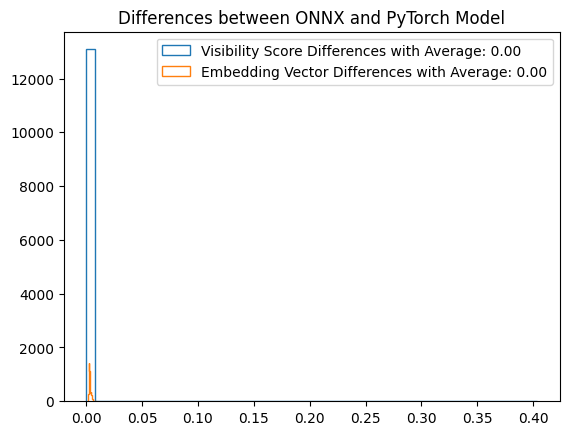

In [13]:
v_diff = []
f_diff = []

count = 0

onnx_v_scores = None
onnx_emb_vecs = None

with torch.no_grad():
    for input_batch, _ in tqdm(re_id_dataloader):
        ort_v_scores, ort_emb_vecs = ort_session.run([Config.v_score_name, Config.emb_vec_name], {Config.input_name: input_batch.numpy()})

        if onnx_v_scores is None:
            onnx_v_scores = ort_v_scores
        else:
            onnx_v_scores = np.concatenate((onnx_v_scores, ort_v_scores), axis=0)

        if onnx_emb_vecs is None:
            onnx_emb_vecs = ort_emb_vecs
        else:
            onnx_emb_vecs = np.concatenate((onnx_emb_vecs, ort_emb_vecs), axis=0)

        trc_v_scores, trc_emb_vecs = export_model(input_batch.to(Config.device))

        ort_v_scores = torch.tensor(ort_v_scores).to(Config.device)
        ort_emb_vecs = torch.tensor(ort_emb_vecs).to(Config.device)

        for i in range(len(trc_emb_vecs)):
            ov = ort_v_scores[i]
            tv = trc_v_scores[i]

            oe = ort_emb_vecs[i]
            te = trc_emb_vecs[i]

            f_diff.append((torch.norm(te - oe)).item())

            v_diff.append((torch.norm(tv - ov)).item())

plt.title("Differences between ONNX and PyTorch Model")

plt.hist(v_diff, label=f"Visibility Score Differences with Average: {sum(v_diff)/len(v_diff):.2f}", bins=50, histtype="step")
plt.hist(f_diff, label=f"Embedding Vector Differences with Average: {sum(f_diff)/len(f_diff):.2f}", bins=50, histtype="step")

plt.legend(loc="best")

plt.show()

In [14]:
v_scores = torch.tensor(onnx_v_scores)
emb_vecs = torch.tensor(onnx_emb_vecs)

MIN_V_SCORE = 0.1

y_true = [[] for _ in range(Config.attention_num + Config.distance_metric.metric_num)]
y_pred = [[] for _ in range(Config.attention_num + Config.distance_metric.metric_num)]

if ONNXExportConfig.filter_by_v_score:
    v_scores_mask = v_scores.amin(dim=1) > MIN_V_SCORE
    valid_indices = v_scores_mask.nonzero(as_tuple=True)[0]
    valid_indices_set = set(valid_indices.tolist())
    
    groups = [[idx for idx in re_id_dataset.get_indexes_by_id(id) if idx in valid_indices_set]
              for id in re_id_dataset.unique_ids]
    groups = [group for group in groups if len(group) > 1]
    print(f'Selected {sum(len(g) for g in groups)} of {len(v_scores)}')
else:
    groups = [re_id_dataset.get_indexes_by_id(id) for id in re_id_dataset.unique_ids]
    groups = [group for group in groups if len(group) > 1]

for src_group in tqdm(groups, desc="Get Scores"):
    for idx1 in src_group:
        for is_same_person in [True, False]:
            # Same Person Comparison
            if is_same_person:
                camera = re_id_dataset.get_camera_by_index(idx1)
                tgt_group = [idx for idx in src_group if idx != idx1]

                all_cam = []
                diff_cam = []
                for idx_cand in tgt_group:
                    all_cam.append(idx_cand)
                    if re_id_dataset.get_camera_by_index(idx_cand) != camera:
                        diff_cam.append(idx_cand)

                # Prioritize images from different cameras
                idx2 = random.choice(diff_cam) if len(diff_cam) > 0 else random.choice(all_cam)
                y = 0

            # Different People Comparison
            else:
                tgt_group_cands = [group for group in groups if group != src_group]
                tgt_group = random.choice(tgt_group_cands)
                idx2 = random.choice(tgt_group)
                y = 1

            final_distances, part_distances = Config.distance_metric.all((v_scores[idx1], emb_vecs[idx1]),
                                                                         (v_scores[idx2], emb_vecs[idx2]))

            for s_idx, final_distance in enumerate(final_distances):
                y_pred[s_idx].append(final_distance.item())
                y_true[s_idx].append(y)

            min_v_scores = torch.cat((v_scores[idx1].unsqueeze(0), v_scores[idx2].unsqueeze(0)), dim=0).min(dim=0).values

            for att_idx in range(Config.attention_num):
                v_score = min_v_scores[att_idx].item()
                if v_score > MIN_V_SCORE:
                    y_pred[att_idx + Config.distance_metric.metric_num].append(part_distances[att_idx].item())
                    y_true[att_idx + Config.distance_metric.metric_num].append(y)

Selected 1970 of 13115


Get Scores:   0%|          | 0/411 [00:00<?, ?it/s]

In [15]:
NUM_PEOPLE = 90
NUM_PIC_PER_PERSON_RANGE = [5, 20]

true_labels = []
pred_labels = []

selected_groups = random.sample(groups, k=min(NUM_PEOPLE, len(groups)))

people = []

print("Sampling People for Clustering...")
for i, group in enumerate(selected_groups):
    r_from = min(NUM_PIC_PER_PERSON_RANGE[0] , len(group))
    r_to = min(NUM_PIC_PER_PERSON_RANGE[1] , len(group))

    if r_from == r_to:
        k = r_from
    else:
        k = random.randrange(r_from, r_to)

    selected_indices = random.sample(group, k=k)

    for selected_idx in selected_indices:
        true_labels.append(i)
        people.append(Person(v_scores=v_scores[selected_idx],
                             emb_vecs=emb_vecs[selected_idx]))

print("Done")

for metric in Config.distance_metric.distance_metrics:
    distance_metric = DistanceMetric(metric)
    def distance_func(person1, person2):
        return Config.distance_metric.metric(metric,
                                             (person1.v_scores, person1.emb_vecs),
                                             (person2.v_scores, person2.emb_vecs)).item()

    print(f"Clustering with metric {metric}...")

    pred_labels.append(cluster_people(people,
                                      Config.default_thresholds[metric],
                                      distance_func))

    print("Done")

# Move to Stat Report to see the result.

Sampling People for Clustering...
Done
Clustering with metric concat_dist...
Done
Clustering with metric dist_mean...
Done


## Stat Report

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, roc_curve, precision_recall_curve,
                             auc, confusion_matrix, ConfusionMatrixDisplay, adjusted_rand_score,
                             normalized_mutual_info_score, adjusted_mutual_info_score, fowlkes_mallows_score)
from sklearn.decomposition import PCA
import numpy as np

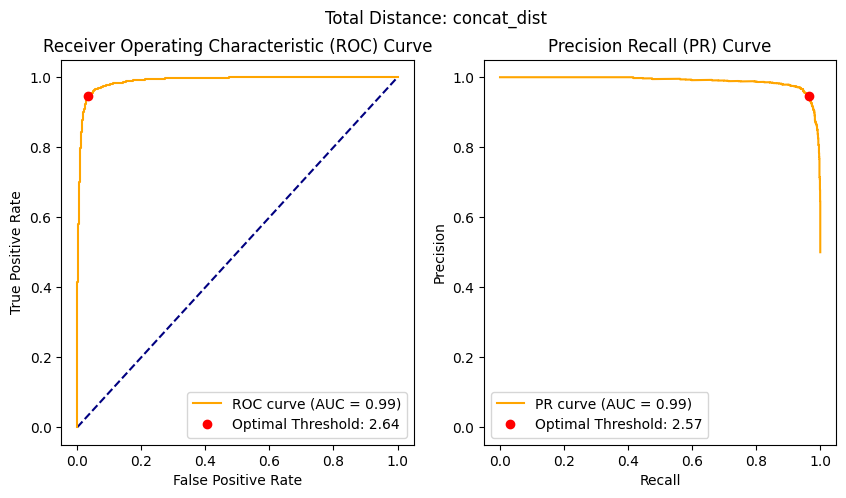

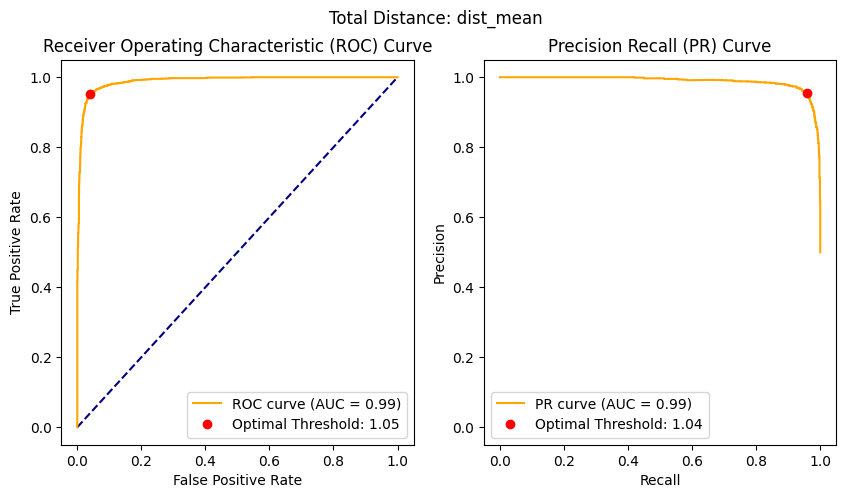

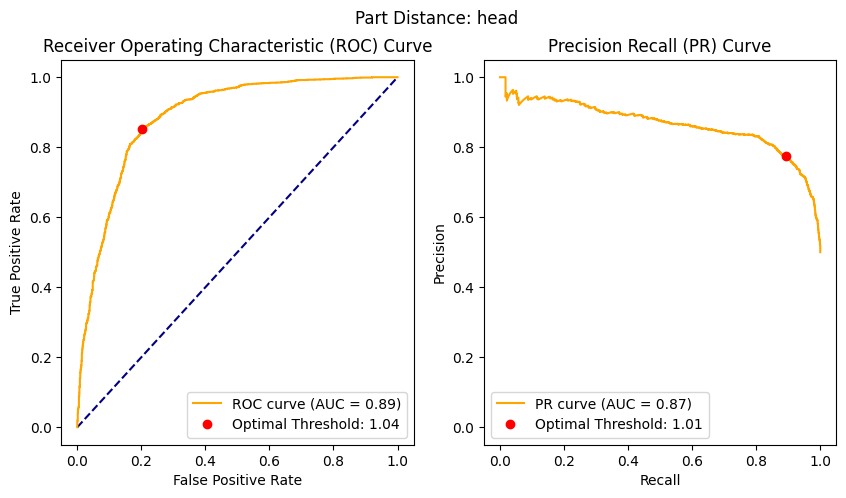

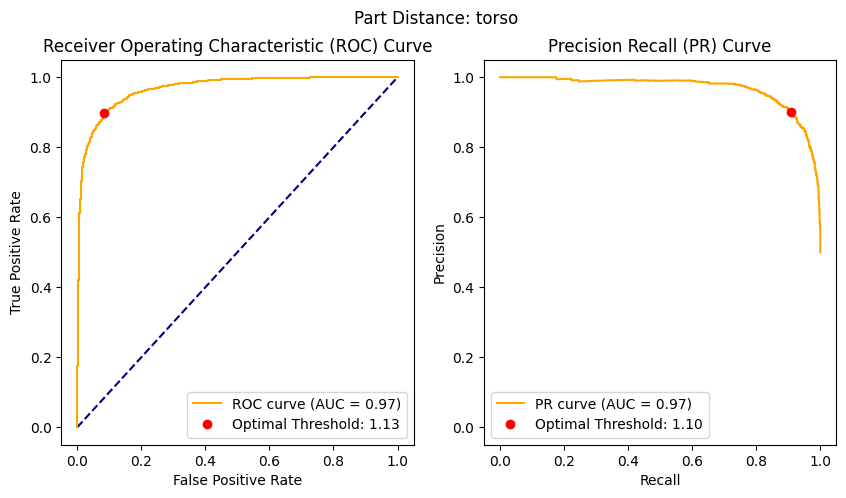

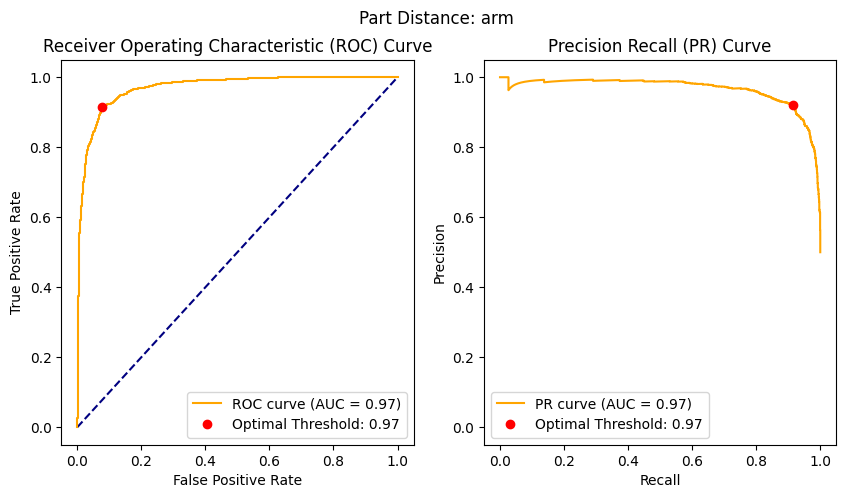

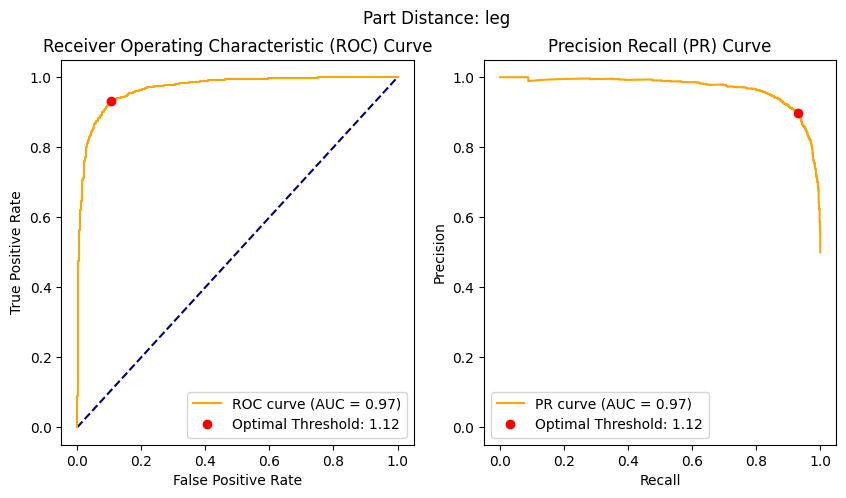

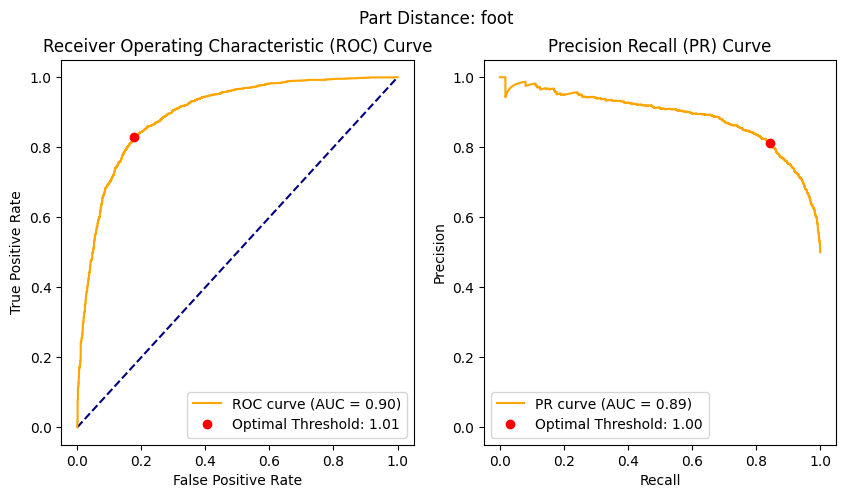

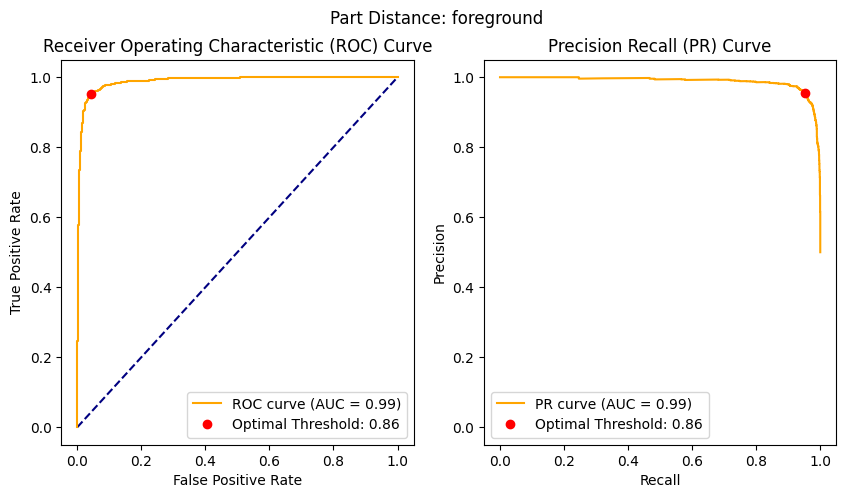

In [17]:
optimal_thresholds = []

for idx in range(Config.attention_num + Config.distance_metric.metric_num):
    title = (f"Total Distance: {Config.distance_metric.distance_metrics[idx]}" if idx < Config.distance_metric.metric_num
             else f"Part Distance: {Config.attention_groups[idx - Config.distance_metric.metric_num]['name']}")

    fpr, tpr, thresholds = roc_curve(y_true[idx], y_pred[idx])
    auc_score = auc(fpr, tpr)

    curve_color = "orange"
    threshold_point_color = "red"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    fig.suptitle(title)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true[idx], y_pred[idx])
    auc_score = auc(fpr, tpr)
    optimal_idx = (tpr - fpr).argmax()
    optimal_threshold = thresholds[optimal_idx]
    optimal_thresholds.append(optimal_threshold)

    ax1.set_xlabel("False Positive Rate")
    ax1.set_ylabel("True Positive Rate")
    ax1.set_xlim([-0.05, 1.05])
    ax1.set_ylim([-0.05, 1.05])
    ax1.set_title("Receiver Operating Characteristic (ROC) Curve")
    ax1.plot([0, 1], [0, 1], linestyle='dashed', color='navy')
    ax1.plot(fpr, tpr, color=curve_color, label="ROC curve (AUC = {:.2f})".format(auc_score))
    ax1.plot(fpr[optimal_idx], tpr[optimal_idx], "o", color=threshold_point_color, label="Optimal Threshold: {:.2f}".format(optimal_threshold))
    ax1.legend(loc='best')

    #PR Curve
    precision, recall, thresholds = precision_recall_curve(y_true[idx], y_pred[idx])
    auc_score = auc(recall, precision)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = f1_scores.argmax()

    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_xlim([-0.05, 1.05])
    ax2.set_ylim([-0.05, 1.05])
    ax2.set_title("Precision Recall (PR) Curve")
    ax2.plot(recall, precision, color=curve_color, label="PR curve (AUC = {:.2f})".format(auc_score))
    ax2.plot(recall[optimal_idx], precision[optimal_idx], "o", color=threshold_point_color, label="Optimal Threshold: {:.2f}".format(thresholds[optimal_idx]))
    ax2.legend(loc='best')

    plt.show()

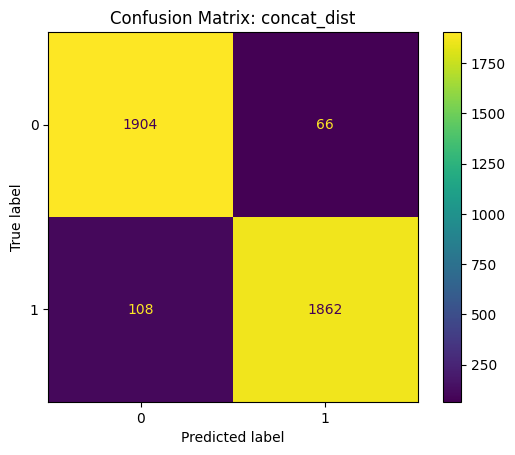

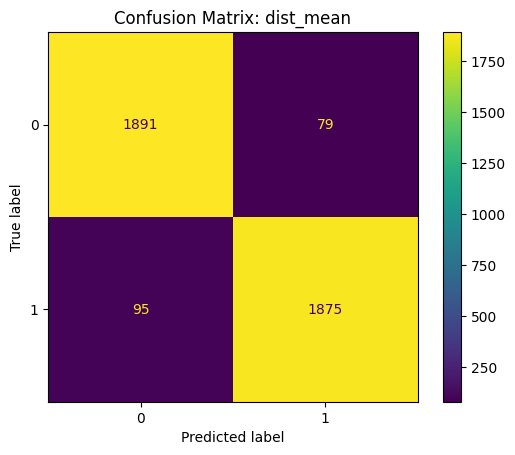

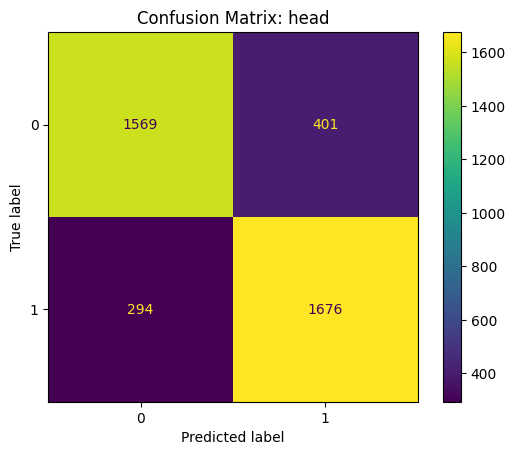

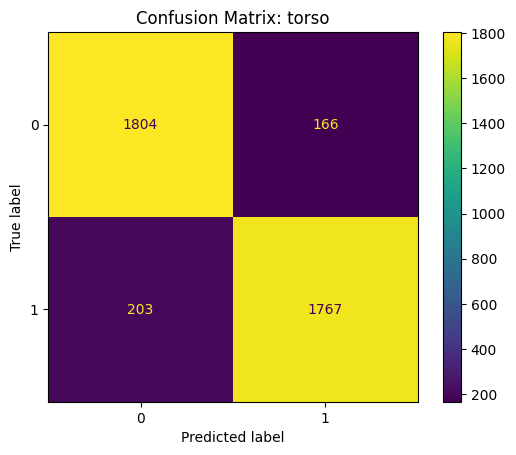

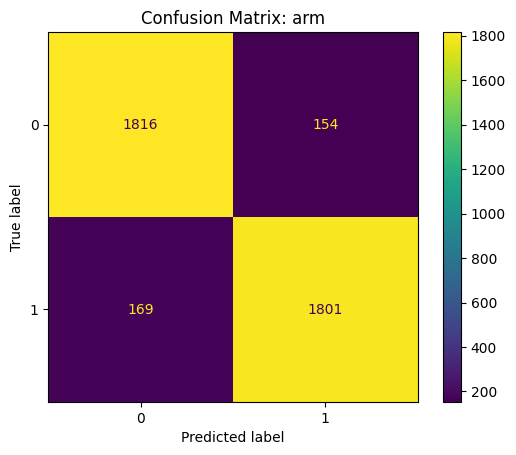

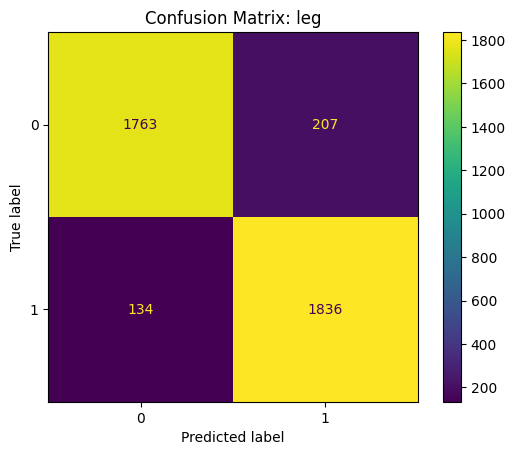

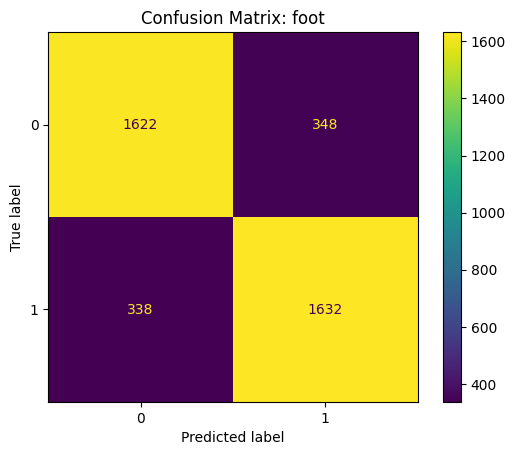

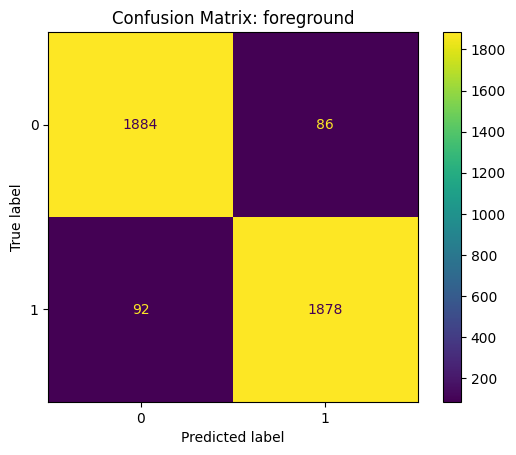

In [18]:
for idx in range(Config.attention_num + Config.distance_metric.metric_num):
    threshold = optimal_thresholds[idx]
    title = (f"Confusion Matrix: {Config.distance_metric.distance_metrics[idx]}" if idx < Config.distance_metric.metric_num
             else f"Confusion Matrix: {Config.attention_groups[idx - Config.distance_metric.metric_num]['name']}")

    disp = ConfusionMatrixDisplay(confusion_matrix(y_true[idx], [0 if y < threshold else 1 for y in y_pred[idx]]))
    disp.plot()
    disp.ax_.set_title(title)
    plt.show()

In [19]:
for idx in range(Config.attention_num + Config.distance_metric.metric_num):
    threshold = optimal_thresholds[idx]
    title = (f"Classification Report: {Config.distance_metric.distance_metrics[idx]}" if idx < Config.distance_metric.metric_num
             else f"Classification Report: {Config.attention_groups[idx - Config.distance_metric.metric_num]['name']}")

    report = classification_report(y_true[idx], [0 if y < threshold else 1 for y in y_pred[idx]])
    print()
    print(f"              {title}")
    print()
    print(report)
    print()


              Classification Report: concat_dist

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1970
           1       0.97      0.95      0.96      1970

    accuracy                           0.96      3940
   macro avg       0.96      0.96      0.96      3940
weighted avg       0.96      0.96      0.96      3940



              Classification Report: dist_mean

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1970
           1       0.96      0.95      0.96      1970

    accuracy                           0.96      3940
   macro avg       0.96      0.96      0.96      3940
weighted avg       0.96      0.96      0.96      3940



              Classification Report: head

              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1970
           1       0.81      0.85      0.83      1970

    accuracy                        

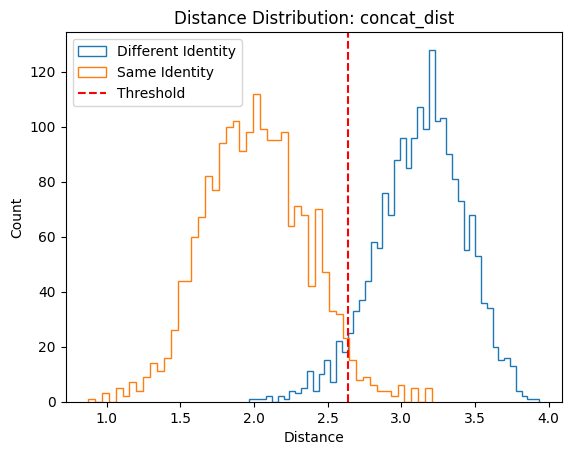

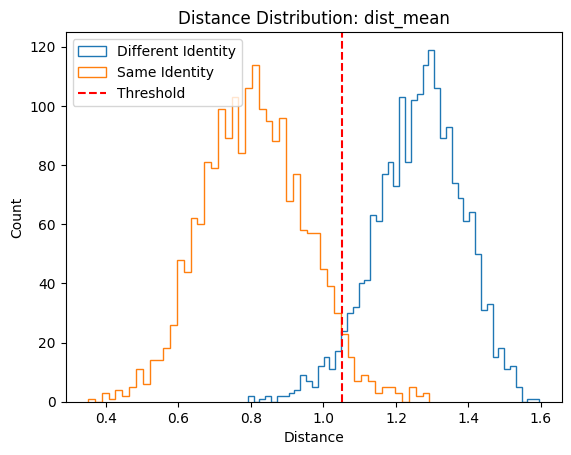

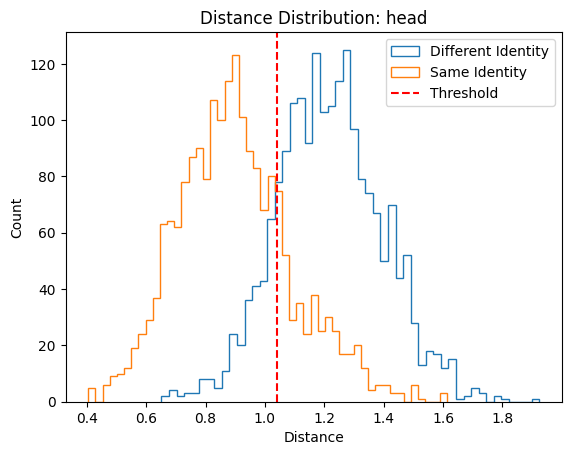

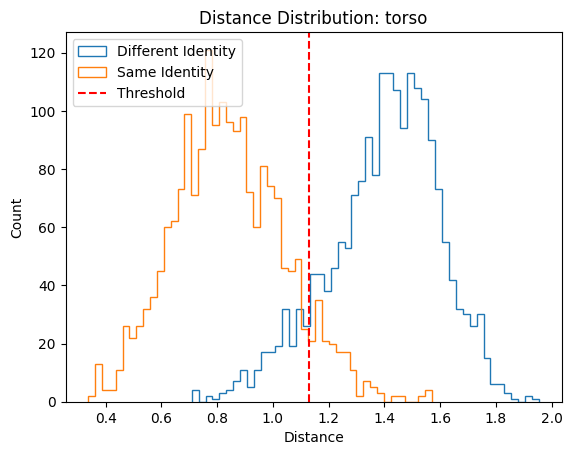

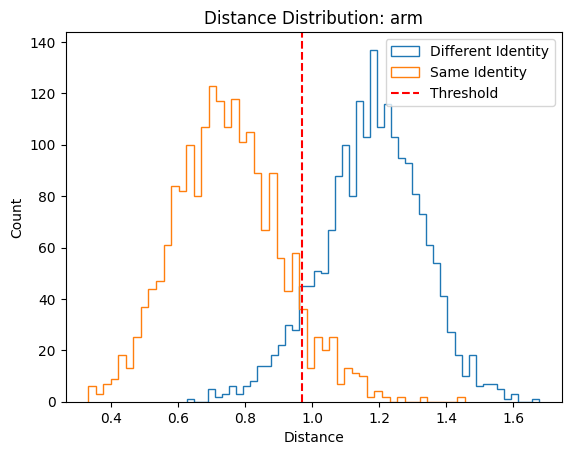

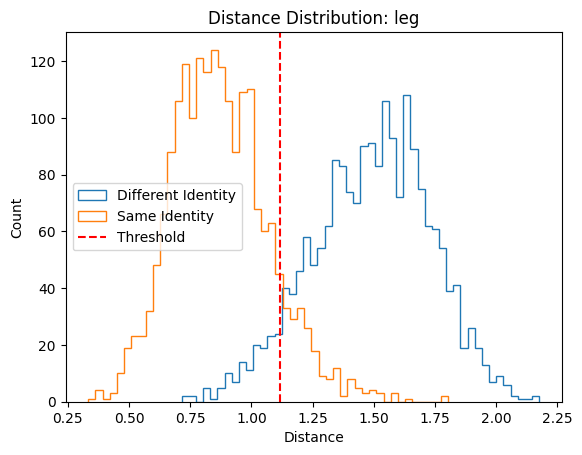

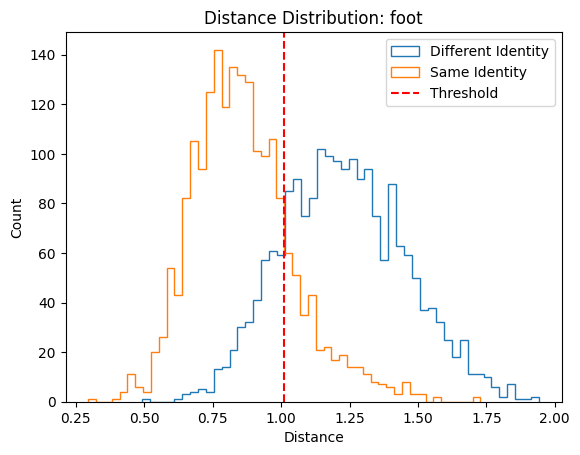

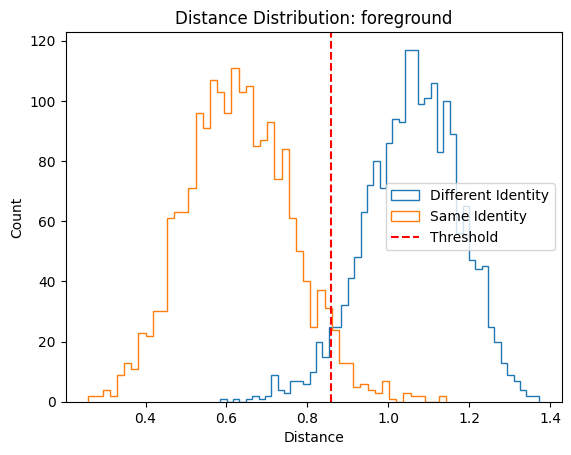

In [20]:
bins = 50

for idx in range(Config.attention_num + Config.distance_metric.metric_num):
    threshold = optimal_thresholds[idx]
    title = (f"Distance Distribution: {Config.distance_metric.distance_metrics[idx]}" if idx < Config.distance_metric.metric_num
             else f"Distance Distribution: {Config.attention_groups[idx - Config.distance_metric.metric_num]['name']}")

    y_true_scores = []
    y_false_scores = []

    for i in range(len(y_true[idx])):
        if y_true[idx][i]:
            y_true_scores.append(y_pred[idx][i])
        else:
            y_false_scores.append(y_pred[idx][i])

    y_true_scores.sort()
    y_false_scores.sort()


    plt.hist(y_true_scores,
             label="Different Identity",
             bins=50, histtype="step")
    plt.hist(y_false_scores,
             label="Same Identity",
             bins=50, histtype="step")

    plt.axvline(x=threshold, color='r', linestyle='dashed', label="Threshold")

    plt.xlabel("Distance")
    plt.ylabel("Count")
    plt.legend(loc="best")

    plt.title(title)

    plt.show()

In [21]:
for idx, metric in enumerate(Config.distance_metric.distance_metrics):

    ari = adjusted_rand_score(true_labels, pred_labels[idx])
    nmi = normalized_mutual_info_score(true_labels, pred_labels[idx])
    ami = adjusted_mutual_info_score(true_labels, pred_labels[idx])
    fmi = fowlkes_mallows_score(true_labels, pred_labels[idx])

    if idx > 0:
        print()
    print(f"Clustering with {metric} Result:")

    print(f"  True Clusters: {max(true_labels) + 1}")
    print(f"  Pred Clusters: {max(pred_labels[idx]) + 1}")

    print()

    print(f"  Adjusted Rand Index: {ari:.2f}")
    print(f"  Normalized Mutual Information: {nmi:.2f}")
    print(f"  Adjusted Mutual Information: {ami:.2f}")
    print(f"  Fowlkes-Mallows Index: {fmi:.2f}")

Clustering with concat_dist Result:
  True Clusters: 90
  Pred Clusters: 93

  Adjusted Rand Index: 0.57
  Normalized Mutual Information: 0.89
  Adjusted Mutual Information: 0.70
  Fowlkes-Mallows Index: 0.58

Clustering with dist_mean Result:
  True Clusters: 90
  Pred Clusters: 72

  Adjusted Rand Index: 0.49
  Normalized Mutual Information: 0.87
  Adjusted Mutual Information: 0.68
  Fowlkes-Mallows Index: 0.52


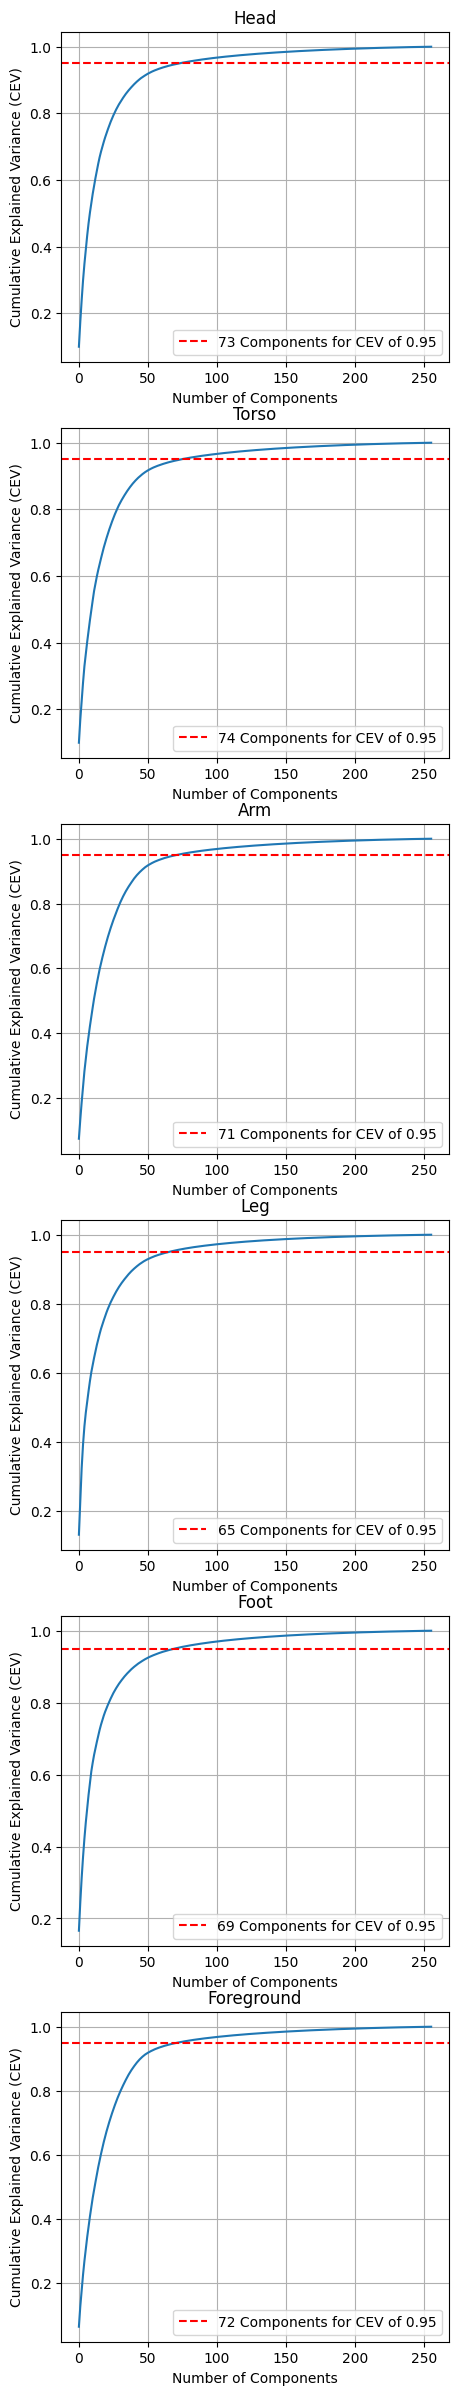

In [22]:
cev_threshold = 0.95

emb_vecs_np = emb_vecs if isinstance(emb_vecs, np.ndarray) else emb_vecs.numpy()

fig, axes = plt.subplots(Config.attention_num, 1, figsize=(5, 5 * Config.attention_num))

for i in range(Config.attention_num):
    name = Config.attention_groups[i]["name"].title()
    ax = axes[i]
    data = emb_vecs_np[:, i]
    pca = PCA().fit(data)
    cev = np.cumsum(pca.explained_variance_ratio_)

    c = next(i for i, x in enumerate(cev) if x >= cev_threshold)

    ax.set_title(name)
    ax.plot(cev)
    ax.axhline(y=cev_threshold, color='r', linestyle='dashed', label=f"{c} Components for CEV of {cev_threshold}")
    ax.set_xlabel("Number of Components")
    ax.set_ylabel("Cumulative Explained Variance (CEV)")
    ax.grid()
    ax.legend(loc='best')

plt.show()

## Benchmark

In [4]:
import os
import torch
from tabulate import tabulate
from torch.utils.data import Dataset, DataLoader
from src.data.reid import get_dataset

In [5]:
class BenchmarkConfig:
    reid_dataset = "market1501" # "market1501", "duke", "nia"
    filter_by_v_score = True

In [6]:
model = ReIDModel(Config.model_variant,
                  Config.seg_variant,
                  Config.emb_len,
                  Config.input_resolution,
                  pretrained=True,
                  backbone_pretrained=False).export().to(Config.device).eval()

In [7]:
def extract_features(model, dataloader, device):
    """
    Extracts features for all images in the dataloader.
    Returns a batch list of (v_scores, emb_vecs) tuples and corresponding PIDs and CamIDs.
    """
    model.eval()
    ft_batches = []
    pid_batches = []
    camid_batches = []
    
    with torch.no_grad():
        for imgs, pid, cid in dataloader:
            imgs = imgs.to(device)
            v_scores, emb_vecs = model(imgs)

            ft_batches.append((v_scores.cpu(), emb_vecs.cpu()))
            pid_batches.append(pid)
            camid_batches.append(cid)
                
    return ft_batches, pid_batches, camid_batches

In [8]:
MIN_V_SCORE = 0.1

def calculate_map_cmc(query_ft_batches, query_pid_batches, query_camid_batches,
                      gallery_ft_batches, gallery_pid_batches, gallery_camid_batches,
                      device):
    """
    Calculates mAP and CMC for the given query and gallery features.
    Follows the standard Market-1501 evaluation protocol.
    """
    q_batches = len(query_ft_batches)
    g_batches = len(gallery_ft_batches)

    distances = torch.FloatTensor()
    v_scores = torch.FloatTensor()
    pid_matches = torch.tensor([], dtype=torch.bool)
    camid_matches = torch.tensor([], dtype=torch.bool)

    num_query = sum(len(b) for b in query_pid_batches)
    num_gallery = sum(len(b) for b in gallery_pid_batches)

    print(f"Evaluating {num_query} queries against {num_gallery} gallery images...")

    for qi in range(q_batches):
        q_vs, q_emb = query_ft_batches[qi]
        q_fts = (q_vs.to(device), q_emb.to(device))
        q_pids = query_pid_batches[qi].unsqueeze(1).to(device)
        q_camids = query_camid_batches[qi].unsqueeze(1).to(device)

        dists = torch.FloatTensor()
        v_scrs = torch.FloatTensor()
        pid_match = torch.tensor([], dtype=torch.bool)
        camid_match = torch.tensor([], dtype=torch.bool)

        for gi in range(g_batches):
            g_vs, g_emb = gallery_ft_batches[gi]
            g_fts = (g_vs.to(device), g_emb.to(device))
            g_pids = gallery_pid_batches[gi].unsqueeze(0).to(device)
            g_camids = gallery_camid_batches[gi].unsqueeze(0).to(device)

            dist, v_score = Config.distance_metric(q_fts, g_fts, cross_batch=True, return_v_scores=True)

            dists = torch.cat((dists, dist.cpu()), 1)
            v_scrs = torch.cat((v_scrs, v_score.cpu()), 2)

            pid_match = torch.cat((pid_match, (q_pids == g_pids).cpu()), 1)
            camid_match = torch.cat((camid_match, (q_camids == g_camids).cpu()), 1)

        distances = torch.cat((distances, dists), 0)
        v_scores = torch.cat((v_scores, v_scrs), 1)
        pid_matches = torch.cat((pid_matches, pid_match), 0)
        camid_matches = torch.cat((camid_matches, camid_match), 0)
    
    print("Calculating Benchmark...")

    orders = distances.argsort(dim=1)
    # Protocol: exclude gallery images with the same PID and same Camera ID as the query
    masks = ~(pid_matches & camid_matches)
    # Only use distances greater or equal to zero
    masks = masks & (distances >= 0)
    if BenchmarkConfig.filter_by_v_score:
        # Only use where all parts are visible
        masks = masks & (v_scores > MIN_V_SCORE).all(dim=0)

    aps = torch.FloatTensor()
    cmc = torch.zeros(num_gallery + 1)

    opt_thresholds = []
    f1_scores = []

    for qi in range(num_query):
        order = orders[qi]

        mask = masks[qi][order]

        if not mask.any():
            continue

        pid_match = pid_matches[qi][order][mask]
        dists = distances[qi][order][mask]

        if not pid_match.any():
            continue

        match_ranks = pid_match.nonzero(as_tuple=True)[0] + 1

        match_order = torch.arange(1, match_ranks.size(0) + 1)
        precisions = match_order / match_ranks

        ap = precisions.mean().unsqueeze(0)

        aps = torch.cat((aps, ap), 0)
        cmc[match_ranks[0]] += 1

    mAP = aps.mean().item()
    cmc = cmc.cumsum(dim=0) / aps.size(0)

    print(f"Done. Total valid queries: {aps.size(0)}")

    return mAP, cmc

In [9]:
# Load query and gallery sets
query_ds = get_dataset(BenchmarkConfig.reid_dataset, Config.input_resolution,
                       "query", no_augment=True, iterate_camera_id=True)
gallery_ds = get_dataset(BenchmarkConfig.reid_dataset, Config.input_resolution,
                         "test", no_augment=True, iterate_camera_id=True)

In [10]:
query_loader = DataLoader(query_ds, batch_size=Config.batch_size, shuffle=False, num_workers=4)
gallery_loader = DataLoader(gallery_ds, batch_size=Config.batch_size, shuffle=False, num_workers=4)

In [11]:
print("Extracting query features...")
query_ft_batches, query_pid_batches, query_camid_batches = extract_features(model, query_loader, Config.device)

print("Extracting gallery features...")
gallery_ft_batches, gallery_pid_batches, gallery_camid_batches = extract_features(model, gallery_loader, Config.device)

Extracting query features...
Extracting gallery features...


In [12]:
# Perform evaluation
mAP, cmc = calculate_map_cmc(query_ft_batches, query_pid_batches, query_camid_batches,
                                                        gallery_ft_batches, gallery_pid_batches, gallery_camid_batches,
                                                        device=Config.device)

Evaluating 3368 queries against 13115 gallery images...
Calculating Benchmark...
Done. Total valid queries: 2448


In [13]:
print(f"Market-1501 Benchmark Results:")
print(tabulate(
    [["mAP", mAP],
     ["Rank-1", cmc[1]],
     ["Rank-5", cmc[5]],
     ["Rank-10", cmc[10]]],
    floatfmt=".4f",
    tablefmt="grid"
))

Market-1501 Benchmark Results:
+---------+--------+
| mAP     | 0.7979 |
+---------+--------+
| Rank-1  | 0.9150 |
+---------+--------+
| Rank-5  | 0.9800 |
+---------+--------+
| Rank-10 | 0.9910 |
+---------+--------+
